# ALS_LLRF_MTS test on ZCU208
---

The following results were captured when looping back all 8 DACs to 8 ADCs through equal-length cables.


### Preparation from a PYNQ 3.0.1 image:

Run installation script: `./pynq_llrf/install.sh`.

In [1]:
%cd /home/xilinx/jupyter_notebooks/pynq_llrf

/home/xilinx/jupyter_notebooks/pynq_llrf


In [2]:
from mimo_mts import MimoMtsOverlay
import numpy as np

%load_ext autoreload
%autoreload 2

##  Configure SI570 to 156.1375 MHz

Due to EVG referece clock is 499.64 / 4 MHz, line rate is 2498.2 MHz.
GTY reference clock needs to be 2498.2 / 8 = 156.1375 MHz.

In [3]:
from mimo_mts.utils.config_si570 import SI570
with SI570() as si570:
    si570.set_freq(156.1375)

In [4]:
# reset PL to remove any cached .hwh file
# from pynq import PL
# PL.reset()

In [5]:
ol = MimoMtsOverlay(
    'als_llrf_mts.bit',
    board = 'ZCU208',
    lmk_tcs='boards/CLK104/DIST_MTS_LMK04828.tcs',
    lmxadc_tcs='boards/CLK104/LMX2594_4000MHz.tcs',
    lmxdac_tcs='boards/CLK104/LMX2594_4000MHz.tcs')
ol.is_loaded()

True

In [6]:
ol.evr.check_frequencies()

In [7]:
ol.evr

GT EVR GTY:      ['xilinx.com:module_ref:axil_evr:1.0']
Event count:     74
GTY ref freq:    156.1370 MHz
GTY RX freq:     124.9105 MHz
Timestamp valid: True
Timestamp:       948045312
GTY status:      0x7
RX aligned:      True

---

### Test deterministic latency incurred due to alignment
Every reboot should result in the same latency and offet \
Example: \
DAC Latency: 128, Offset: 0 \
ADC Latency:  96, Offset: 0

In [8]:
for i in range(4):
    print(f"DAC Tile {i} Latency: {ol.xrfdc.mts_dac_config.Latency[i]:3d}, "
          f"Offset: {ol.xrfdc.mts_dac_config.Offset[i]}\n"
          f"ADC Tile {i} Latency: {ol.xrfdc.mts_adc_config.Latency[i]:3d}, "
          f"Offset: {ol.xrfdc.mts_adc_config.Offset[i]}")

DAC Tile 0 Latency: 128, Offset: 8
ADC Tile 0 Latency:  96, Offset: 8
DAC Tile 1 Latency: 128, Offset: 8
ADC Tile 1 Latency:  96, Offset: 8
DAC Tile 2 Latency: 128, Offset: 8
ADC Tile 2 Latency:  96, Offset: 8
DAC Tile 3 Latency: 128, Offset: 8
ADC Tile 3 Latency:  96, Offset: 8


# Configure trigger

internal, 1 Hz

In [9]:
ol.rf_control.register_map.trig_period = 250e6
ol.rf_control.register_map.trig_sel = 1  # EVR trigger
ol.rf_control.register_map.trig_delay = 0
ol.rf_control.register_map.trig_divide = 1
ol.rf_control.register_map.dac_enable = 1
ol.rf_control.register_map.pulse_length = 0xfff

### Set DAC baseband waveform as DC, reset mixer

In [10]:
n_samples = ol.dac_player.size
ol.dac_player[:] = np.ones(n_samples, dtype=np.int16) * 32767
# ol.set_dac_mixer_dco(0)
# ol.set_adc_mixer_dco(0)

In [11]:
from mimo_mts.utils.plot import plot_adc_wfm, plot_complex_wfm_stack

fs = ol.board.adc_sampling_rate
start = 1149 # start of the signal
print(f'RF loop back latency: {start/fs * 1e9} ns')

Matplotlib is building the font cache; this may take a moment.


RF loop back latency: 287.25 ns


In [12]:
ol.set_dac_mixer_dco(125)

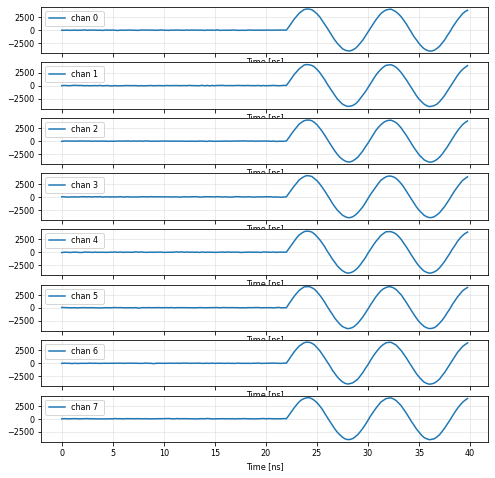

In [13]:
darray_i, darray_q = ol.capture_adc_iq_buf();
plot_adc_wfm(darray_i[:, start-80:start+80], fs=fs)